<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/18_classification/18_1_Classification_Basics/18_1_3_Model_Selection_Multiclass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification: Predicting Credit Default: Part 4
## Model Selection and Multiclass

**Author:** Brad Sheese

---

## Introduction: Picking the Winner

Up to this point, we have used logistic regression exclusively. But just as in our regression notebooks, there are many algorithms we can choose from—Decision Trees, Random Forests, Support Vector Machines (SVMs), and more.

This notebook is divided into two parts:
1.  **Part A: Model Competition** — We will use cross-validation and information criteria (AIC/BIC) to pick the best model for our Credit Default data.
2.  **Part B: Entering the Multiclass World** — What if we have more than two categories? We will introduce the wine dataset and explore how models handle multiple classes.

### Learning Objectives
By the end of this notebook, you will be able to:
1.  Compare multiple model types using cross-validation with multiple scoring metrics.
2.  Understand the trade-off between goodness of fit and model complexity using AIC and BIC.
3.  Explain the difference between One-vs-Rest (OvR) and Softmax (Multinomial) multiclass strategies.
4.  Apply classification metrics to a balanced multiclass dataset.

## Part A: Model Competition

### Section 1: Setup — The Credit Default Data

We'll start by loading our familiar Credit Default data one last time to compare different algorithms.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

data = fetch_openml(name='credit-g', version=1, as_frame=True)
df = data.frame
y = (df['class'] == 'bad').astype(int)
X = df.drop(columns=['class'])
X_encoded = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data loaded and ready for competition!")

Data loaded and ready for competition!


### Section 2: Model Competition via Cross-Validation

Just like in our Regression Part 2 notebook, we don't want to rely on a single train/test split. We will use 5-fold cross-validation to find the model that generalizes best to unseen data.

We will test four competitors:
1.  **Logistic Regression** — Our baseline (linear decision boundary)
2.  **Decision Tree (depth=3)** — Simple, interpretable rules
3.  **Random Forest (50 trees, depth=5)** — An ensemble of many trees
4.  **SVM (RBF kernel)** — Captures complex non-linear boundaries

We'll score each model on **both accuracy and F1** — because accuracy alone can be misleading on imbalanced data.

Logistic Regression      : Acc = 0.686 (+/- 0.020)  |  F1 = 0.556 (+/- 0.029)
Decision Tree (d=3)      : Acc = 0.636 (+/- 0.057)  |  F1 = 0.582 (+/- 0.037)


Random Forest            : Acc = 0.719 (+/- 0.032)  |  F1 = 0.574 (+/- 0.036)


SVM (RBF)                : Acc = 0.704 (+/- 0.031)  |  F1 = 0.567 (+/- 0.048)


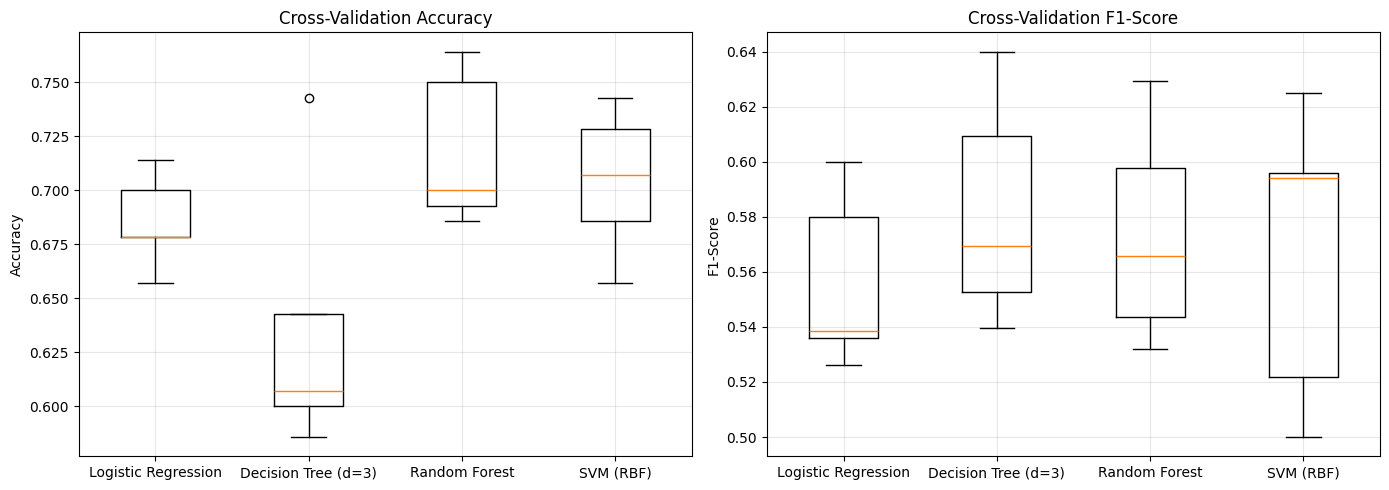

In [2]:
models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'), X_train_scaled),
    'Decision Tree (d=3)': (DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced'), X_train),
    'Random Forest': (RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, class_weight='balanced'), X_train),
    'SVM (RBF)': (SVC(kernel='rbf', probability=True, random_state=42, class_weight='balanced'), X_train_scaled)
}

cv_accuracy = {}
cv_f1 = {}

for name, (model, X_feat) in models.items():
    acc_scores = cross_val_score(model, X_feat, y_train, cv=5, scoring='accuracy')
    f1_scores = cross_val_score(model, X_feat, y_train, cv=5, scoring='f1')
    cv_accuracy[name] = acc_scores
    cv_f1[name] = f1_scores
    print(f"{name:<25}: Acc = {acc_scores.mean():.3f} (+/- {acc_scores.std():.3f})  |  F1 = {f1_scores.mean():.3f} (+/- {f1_scores.std():.3f})")

# Visualize both metrics side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.boxplot(cv_accuracy.values(), tick_labels=cv_accuracy.keys())
ax1.set_title('Cross-Validation Accuracy')
ax1.set_ylabel('Accuracy')
ax1.grid(True, alpha=0.3)

ax2.boxplot(cv_f1.values(), tick_labels=cv_f1.keys())
ax2.set_title('Cross-Validation F1-Score')
ax2.set_ylabel('F1-Score')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interpreting the Results

Look at both metrics together:

- **Accuracy** tells you the overall correctness. A model that gets all the majority class right but misses the minority class can still have high accuracy.
- **F1** tells you how well the model handles the minority class (defaults). A big gap between accuracy and F1 means the model is biased toward the majority class.

The **variance** (spread of each box) tells you how consistent the model is across different data splits. A wide box means the model's performance depends heavily on which specific samples end up in each fold — a sign of instability.

Notice that the Random Forest and SVM typically outperform the single Decision Tree. This is the power of ensembling (RF) and non-linear boundaries (SVM) over a single shallow tree.

### Section 3: Evaluating Complexity (AIC and BIC)

Recall from Regression: we don't just want the model with the highest score; we want the simplest model that does the job well.

- **AIC** (Akaike Information Criterion) and **BIC** (Bayesian Information Criterion) penalize models for having too many parameters.
- **Lower is better.**
- A difference of 2-7 in AIC suggests the lower model is meaningfully better. A difference >10 is strong evidence.

Note: AIC/BIC only apply to parametric models like logistic regression. Trees and forests don't have a fixed number of parameters in the same way, so we rely on cross-validation alone for those.

Let's compare a full model against one using only the most important features (selected by their absolute coefficient magnitude).

In [3]:
def calc_aic_bic(model, X, y):
    n = len(y)
    log_likelihood = model.predict_log_proba(X)[np.arange(len(y)), y].sum()
    k = model.coef_.shape[1] + 1  # coefficients + intercept
    aic = 2*k - 2*log_likelihood
    bic = k * np.log(n) - 2*log_likelihood
    return aic, bic, k

# Full model
full_lr = LogisticRegression(max_iter=1000, random_state=42)
full_lr.fit(X_train_scaled, y_train)
f_aic, f_bic, f_k = calc_aic_bic(full_lr, X_train_scaled, y_train)

# Restricted model: select top 10 features by absolute coefficient
coefs = np.abs(full_lr.coef_[0])
top_10_idx = np.argsort(coefs)[-10:]
X_train_top10 = X_train_scaled[:, top_10_idx]

restricted_lr = LogisticRegression(max_iter=1000, random_state=42)
restricted_lr.fit(X_train_top10, y_train)
r_aic, r_bic, r_k = calc_aic_bic(restricted_lr, X_train_top10, y_train)

print(f"{'Model':<30} {'Params':>6} {'AIC':>10} {'BIC':>10}")
print(f"{'-'*56}")
print(f"{'Full Model (48 features)':<30} {f_k:>6} {f_aic:>10.1f} {f_bic:>10.1f}")
print(f"{'Restricted Model (10 features)':<30} {r_k:>6} {r_aic:>10.1f} {r_bic:>10.1f}")
print(f"\nAIC difference: {f_aic - r_aic:.1f} (positive means restricted is better)")
print(f"BIC difference: {f_bic - r_bic:.1f}")

Model                          Params        AIC        BIC
--------------------------------------------------------
Full Model (48 features)           49      722.7      945.8
Restricted Model (10 features)     11      713.0      763.1

AIC difference: 9.7 (positive means restricted is better)
BIC difference: 182.7


### What This Tells Us

If the restricted model has a lower AIC/BIC despite having fewer features, it means the full model's extra parameters aren't adding enough explanatory power to justify their complexity. This is the same principle behind regularization: simpler models that perform similarly are preferred because they're less likely to overfit.

---

## Part B: Entering the Multiclass World

### Section 4: The Wine Dataset

So far we've been predicting binary outcomes: default or not. But many real problems have 3+ categories: wine type, disease severity, customer segment.

We'll switch to the **Wine dataset**, which contains the results of a chemical analysis of wines grown in the same region in Italy but derived from three different cultivars (varieties). Our task: predict which of the three cultivars a wine belongs to based on its chemical properties.

In [4]:
from sklearn.datasets import load_wine

wine = load_wine()
X_wine = wine.data
y_wine = wine.target

print("Wine Dataset Properties:")
print(f"Classes: {wine.target_names}")
print(f"Class Distribution: {np.bincount(y_wine)}")
print(f"Features: {wine.feature_names}")

X_w_train, X_w_test, y_w_train, y_w_test = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=42, stratify=y_wine
)
scaler_w = StandardScaler()
X_w_train_s = scaler_w.fit_transform(X_w_train)
X_w_test_s = scaler_w.transform(X_w_test)

Wine Dataset Properties:
Classes: ['class_0' 'class_1' 'class_2']
Class Distribution: [59 71 48]
Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


### Section 5: Multiclass Strategies (OvR vs. Softmax)

Standard algorithms like logistic regression are binary by nature. To handle K classes, they use one of two strategies:

1.  **One-vs-Rest (OvR):** The model trains K separate binary classifiers. (Class 0 vs. Not-0, Class 1 vs. Not-1, etc.) The winner is the one with the highest probability.
2.  **Softmax (Multinomial):** The model has K outputs that are forced to sum to 1.0. This is a single, more complex optimization problem that considers all classes simultaneously.

Let's compare both strategies on the wine dataset.

OvR Test Accuracy:      1.000
Softmax Test Accuracy:  0.972


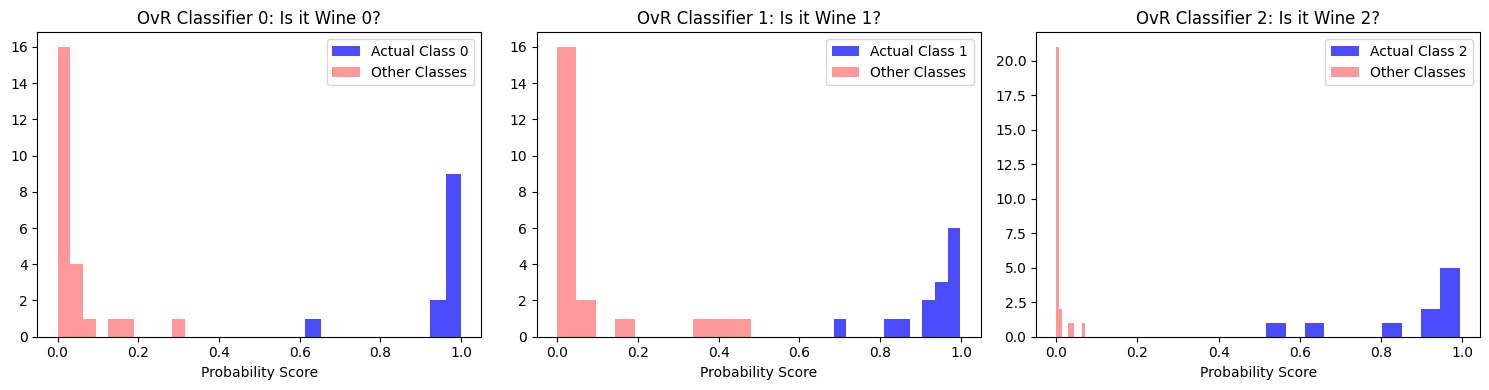

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

# OvR strategy (using OneVsRestClassifier wrapper)
ovr_lr = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42))
ovr_lr.fit(X_w_train_s, y_w_train)

# Softmax (Multinomial) strategy — this is the default in modern sklearn
softmax_lr = LogisticRegression(max_iter=1000, random_state=42)
softmax_lr.fit(X_w_train_s, y_w_train)

print(f"OvR Test Accuracy:      {ovr_lr.score(X_w_test_s, y_w_test):.3f}")
print(f"Softmax Test Accuracy:  {softmax_lr.score(X_w_test_s, y_w_test):.3f}")

# Visualize OvR probability distributions
y_w_proba_ovr = ovr_lr.predict_proba(X_w_test_s)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i in range(3):
    axes[i].hist(y_w_proba_ovr[y_w_test == i, i], bins=10, alpha=0.7, label=f'Actual Class {i}', color='blue')
    axes[i].hist(y_w_proba_ovr[y_w_test != i, i], bins=10, alpha=0.4, label='Other Classes', color='red')
    axes[i].set_title(f'OvR Classifier {i}: Is it Wine {i}?')
    axes[i].set_xlabel('Probability Score')
    axes[i].legend()
plt.tight_layout()
plt.show()

### Reading the OvR Histograms

Each plot shows one binary classifier's probability scores:

- **Blue bars** are wines that actually belong to that class. They should cluster near 1.0 (the classifier is confident).
- **Red bars** are wines from other classes. They should cluster near 0.0 (the classifier correctly rejects them).

Where the blue and red distributions overlap, the classifier is confused. Notice that Classifier 1 (middle plot) has the most overlap — some non-class-1 wines look enough like class 1 to get moderate probability scores. This is where misclassifications happen.

Now let's see the full evaluation with a confusion matrix and classification report.

In [6]:
y_w_pred = softmax_lr.predict(X_w_test_s)

# Confusion matrix
cm = confusion_matrix(y_w_test, y_w_pred)
print("Confusion Matrix (Softmax):")
print(cm)

# Classification report
print("\nClassification Report:")
print(classification_report(y_w_test, y_w_pred, target_names=wine.target_names))

Confusion Matrix (Softmax):
[[12  0  0]
 [ 0 14  0]
 [ 0  1  9]]

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



### Reading the Multiclass Report

- **Per-class precision/recall** tells you how well the model handles each wine type individually. Some cultivars may be easier to distinguish than others.
- **Macro avg** treats all three classes equally, regardless of how many samples each has. This is the fairest measure when classes are balanced.
- **Weighted avg** weights each class by its support (number of samples). Since the wine dataset is roughly balanced, macro and weighted averages will be similar.

Notice that the confusion matrix diagonal shows correct predictions, while off-diagonal cells show which classes the model confuses. If class 0 and class 2 are frequently mixed up, those two cultivars share similar chemical properties.

## Conclusion

We've transitioned from choosing models for binary problems to understanding how models scale to multiple classes. Key takeaways:

1. **Cross-validation with multiple metrics** is the gold standard for picking a model. Don't rely on accuracy alone — especially on imbalanced data.
2. **AIC/BIC help avoid overfitting** by penalizing complexity, but they only apply to parametric models like logistic regression. For trees and forests, cross-validation is your tool.
3. **Multiclass problems are handled automatically by sklearn** — but you should always check per-class performance, not just the overall average. Some classes may be much harder to predict than others.
4. **OvR and Softmax are two different strategies** for extending binary classifiers to multiclass. OvR trains K independent models; Softmax trains one model with K outputs that compete against each other.

In our final notebook, Part 5, we will look at ensemble methods for classification and visualize the decision boundaries that different algorithms create.